## 03 — Modeling

### Objective
### Evaluate predictive power of features and retained customers.

In [7]:
import pandas as pd
customer_df = pd.read_csv("../data/customer_df.csv")

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Features & target
X = customer_df[['avg_days_between_orders', 'total_orders', 'avg_delivery_delay', 'is_multi']]
y = customer_df['churn']

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale AFTER split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train ONLY on train
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predict on test
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc:.3f}")

# Coefs
for col, coef in zip(X.columns, model.coef_[0]):
    print(f"{col}: {coef:.3f}")

AUC: 0.669
avg_days_between_orders: -0.533
total_orders: -0.160
avg_delivery_delay: -0.144
is_multi: 0.002


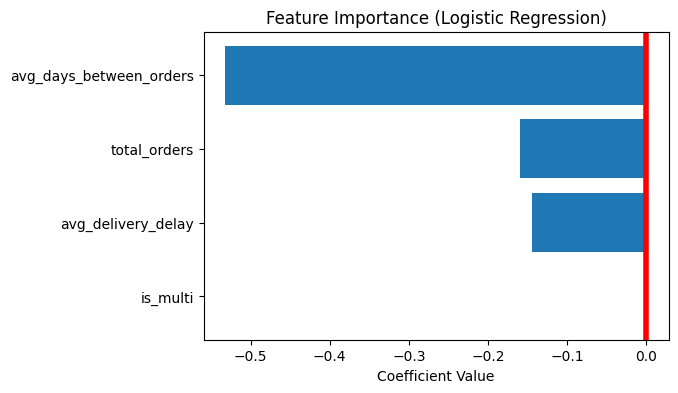

In [9]:
import matplotlib.pyplot as plt


# Get coefficients
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

# Sort by absolute importance
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=True)

# Plot
plt.figure(figsize=(6,4))
plt.axvline(0, color = 'red',linewidth=4)  # adds reference line
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Logistic Regression)")
plt.show()

A logistic regression model achieved moderate predictive performance (AUC ≈ 0.67), indicating limited but meaningful ability to distinguish churned from retained customers.        

Among the features, purchase timing (avg_days_between_orders) is the dominant signal, with a substantially larger coefficient than all other variables. This aligns with earlier analysis showing a clear behavioral difference in inter-purchase intervals between churned and retained customers.

In contrast, order count and delivery delay contribute weakly to the model, while category breadth (is_multi) has a negligible effect, providing no meaningful improvement in predictive performance.

Overall, churn in this dataset appears to be driven primarily by behavioral patterns—specifically purchase timing—rather than transactional volume or delivery experience. The modest model performance suggests that additional features (e.g., pricing, product satisfaction, or customer engagement signals) would be required for stronger prediction.